# 🤖 Reinforcement Learning Practical Handbook in Python

---

Welcome to the **Reinforcement Learning (RL) Practical Handbook**  a comprehensive, hands-on guide covering everything from the mathematical foundations of Markov Decision Processes to Deep Q-Networks and Policy Gradients with OpenAI Gym.

### 📚 Table of Contents
1. Introduction to Reinforcement Learning
2. Markov Decision Processes (MDPs)
3. Dynamic Programming : Value & Policy Iteration
4. OpenAI Gym Environments
5. Q-Learning & Q-Tables
6. Deep Q-Networks (DQN)
7. Policy Gradient Methods (REINFORCE)
8. Actor-Critic Methods
9. Reward Shaping & Exploration Strategies
10. Mini Project : Training a DQN Agent End-to-End

---


In [1]:

!pip install gymnasium torch numpy matplotlib seaborn pandas --quiet
!pip install gymnasium[classic-control] --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
from collections import defaultdict, deque

# Global style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)



---
## Section 1: Introduction to Reinforcement Learning

### What is Reinforcement Learning?

**Reinforcement Learning (RL)** is a type of machine learning where an **agent** learns to make decisions by interacting with an **environment** to maximise cumulative **reward**.

Unlike supervised learning (labeled data) or unsupervised learning (pattern discovery), RL learns from **trial and error** through experience.

### The RL Loop
```
         ┌─────────────────────────────────────────────┐
         │                                             │
         ▼                                             │
   ┌───────────┐   Action a_t   ┌───────────────┐     │
   │           │ ────────────▶  │               │     │
   │   AGENT   │                │  ENVIRONMENT  │     │
   │           │ ◀────────────  │               │     │
   └───────────┘  State  s_t+1  └───────────────┘     │
                  Reward r_t+1                         │
         │                                             │
         └─────────────────────────────────────────────┘
```

### Core Concepts
| Concept | Symbol | Description |
|---|---|---|
| **State** | `s` | A representation of the environment at a given time |
| **Action** | `a` | A decision the agent can make |
| **Reward** | `r` | Scalar feedback signal from the environment |
| **Policy** | `π(a|s)` | The agent's strategy — maps states to actions |
| **Value Function** | `V(s)` | Expected cumulative reward from state `s` |
| **Q-Function** | `Q(s,a)` | Expected cumulative reward from `(state, action)` pair |
| **Discount Factor** | `γ` | How much to value future rewards (0 = myopic, 1 = far-sighted) |

### RL Algorithm Taxonomy
```
Reinforcement Learning
├── Model-Based (knows environment dynamics)
│   ├── Value Iteration
│   └── Policy Iteration
└── Model-Free (learns from experience)
    ├── Value-Based
    │   ├── Q-Learning (tabular)
    │   └── DQN, Double DQN, Dueling DQN (deep)
    ├── Policy-Based
    │   └── REINFORCE, PPO, TRPO
    └── Actor-Critic
        └── A2C, A3C, SAC, TD3
```

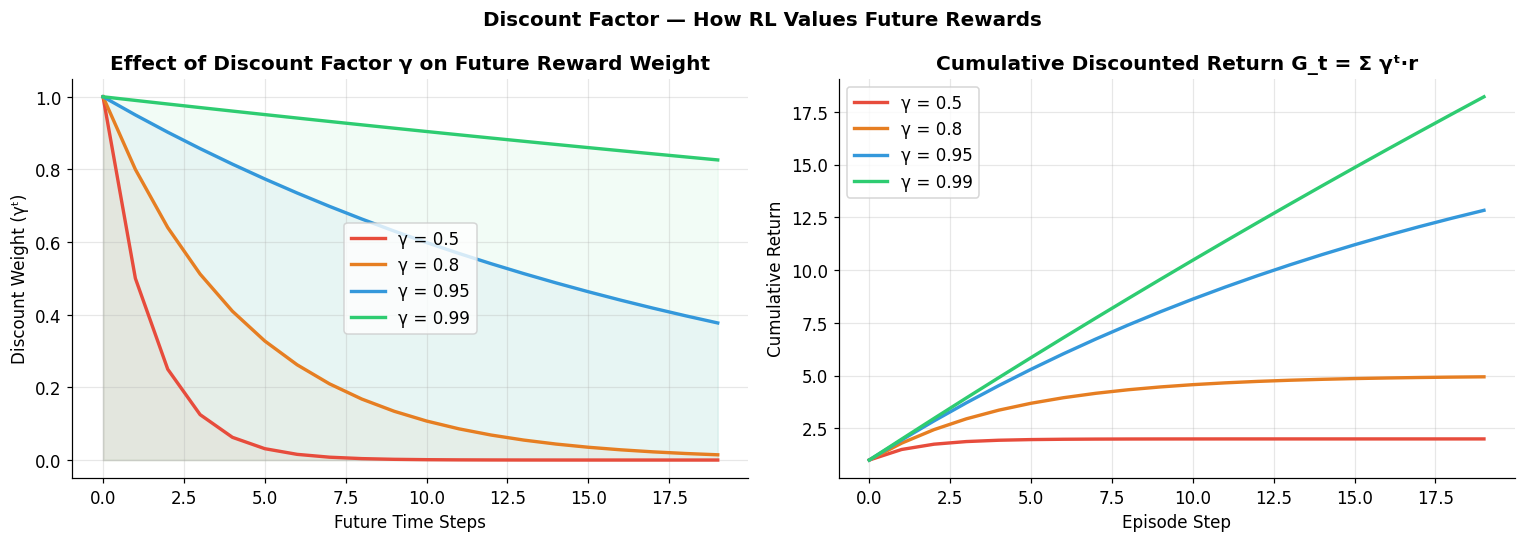

In [2]:
# Section 1 — Visualise the RL taxonomy and reward concept

import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch
import numpy as np

# Visualise: Discount factor effect on future rewards 
time_steps = np.arange(0, 20)
raw_reward = np.ones(20)   # reward of +1 at every step

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discounted rewards for different gamma
gammas = [0.5, 0.8, 0.95, 0.99]
colors_g = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
for gamma, color in zip(gammas, colors_g):
    discounted = [gamma**t for t in time_steps]
    axes[0].plot(time_steps, discounted, color=color, linewidth=2.2,
                 label=f'γ = {gamma}')
    axes[0].fill_between(time_steps, discounted, alpha=0.06, color=color)

axes[0].set_title('Effect of Discount Factor γ on Future Reward Weight',
                   fontweight='bold')
axes[0].set_xlabel('Future Time Steps')
axes[0].set_ylabel('Discount Weight (γᵗ)')
axes[0].legend()

# Cumulative return for different gamma
for gamma, color in zip(gammas, colors_g):
    returns = [sum(gamma**t * raw_reward[t] for t in range(T+1))
               for T in time_steps]
    axes[1].plot(time_steps, returns, color=color, linewidth=2.2,
                 label=f'γ = {gamma}')

axes[1].set_title('Cumulative Discounted Return G_t = Σ γᵗ·r', fontweight='bold')
axes[1].set_xlabel('Episode Step')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend()

plt.suptitle('Discount Factor — How RL Values Future Rewards', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()



---
## Section 2: Markov Decision Processes (MDPs)

An **MDP** is the mathematical framework for RL problems. It is defined by the tuple **(S, A, P, R, γ)**:

| Symbol | Name | Meaning |
|---|---|---|
| **S** | State Space | Set of all possible states |
| **A** | Action Space | Set of all possible actions |
| **P(s'\|s,a)** | Transition Probability | Probability of moving to state s' given (s,a) |
| **R(s,a,s')** | Reward Function | Reward received for transition |
| **γ** | Discount Factor | Weight of future rewards |

### The Markov Property
> *"The future depends only on the present state, not on the history of past states."*
> ```
> P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, ...) = P(s_{t+1} | s_t, a_t)
> ```

### Bellman Equations
The **Bellman Expectation Equation** is the recursive relationship at the core of RL:
```
V(s) = Σ_a π(a|s) · Σ_s' P(s'|s,a) · [R(s,a,s') + γ · V(s')]

Q(s,a) = Σ_s' P(s'|s,a) · [R(s,a,s') + γ · max_a' Q(s',a')]
```

### Example: Grid World MDP
We'll build a simple **4×4 Grid World** MDP from scratch:
- Agent starts at (0,0), goal at (3,3)
- Actions: Up, Down, Left, Right
- Reward: +10 at goal, −1 per step, −5 for hitting a wall

In [3]:
class GridWorldMDP:
    """
    A simple 4x4 grid world MDP.
    States  : (row, col) positions — 16 total
    Actions : 0=Up, 1=Down, 2=Left, 3=Right
    Rewards : +10 goal, -1 step, -5 wall bump
    """
    def __init__(self, size=4):
        self.size     = size
        self.n_states  = size * size
        self.n_actions = 4
        self.goal      = (size-1, size-1)   # bottom-right
        self.start     = (0, 0)             # top-left

        # Optional obstacles
        self.obstacles = {(1, 1), (2, 2), (1, 3)}

        # Action deltas: Up, Down, Left, Right
        self.action_deltas = [(-1,0), (1,0), (0,-1), (0,1)]
        self.action_names  = ['↑ Up', '↓ Down', '← Left', '→ Right']

    def state_to_idx(self, s):
        return s[0] * self.size + s[1]

    def idx_to_state(self, idx):
        return (idx // self.size, idx % self.size)

    def is_valid(self, s):
        r, c = s
        return (0 <= r < self.size and
                0 <= c < self.size and
                s not in self.obstacles)

    def step(self, state, action):
        """Returns (next_state, reward, done)"""
        if state == self.goal:
            return state, 0, True

        dr, dc    = self.action_deltas[action]
        next_state = (state[0] + dr, state[1] + dc)

        if not self.is_valid(next_state):
            next_state = state     # bounce back
            reward     = -5        # wall penalty
        elif next_state == self.goal:
            reward = 10
        else:
            reward = -1

        done = (next_state == self.goal)
        return next_state, reward, done

    def get_all_transitions(self):
        """
        Build the full transition / reward table:
        P[s][a] = (next_state, reward, done)
        """
        P = {}
        for r in range(self.size):
            for c in range(self.size):
                s = (r, c)
                if s in self.obstacles:
                    continue
                P[s] = {}
                for a in range(self.n_actions):
                    P[s][a] = self.step(s, a)
        return P

# Instantiate and inspect
env_mdp = GridWorldMDP(size=4)
P       = env_mdp.get_all_transitions()

print('  Grid World MDP')
print(f'   States  : {env_mdp.n_states} ({env_mdp.size}×{env_mdp.size} grid)')
print(f'   Actions : {env_mdp.n_actions} ({env_mdp.action_names})')
print(f'   Goal    : {env_mdp.goal}')
print(f'   Obstacles: {env_mdp.obstacles}')

print('\n📋 Sample Transitions from state (0,0):')
for a, (ns, r, d) in P[(0,0)].items():
    print(f'   Action {env_mdp.action_names[a]:8s} → next={ns}, reward={r:+d}, done={d}')

  Grid World MDP
   States  : 16 (4×4 grid)
   Actions : 4 (['↑ Up', '↓ Down', '← Left', '→ Right'])
   Goal    : (3, 3)
   Obstacles: {(1, 1), (1, 3), (2, 2)}

📋 Sample Transitions from state (0,0):
   Action ↑ Up     → next=(0, 0), reward=-5, done=False
   Action ↓ Down   → next=(1, 0), reward=-1, done=False
   Action ← Left   → next=(0, 0), reward=-5, done=False
   Action → Right  → next=(0, 1), reward=-1, done=False


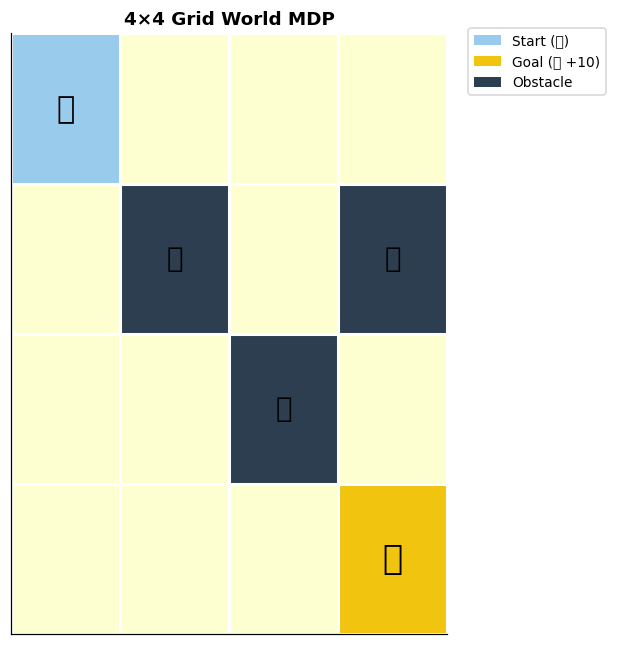

In [4]:
# Visualise the Grid World 
def plot_grid_world(env, title='Grid World MDP', values=None, policy=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    cmap = plt.cm.RdYlGn

    for r in range(env.size):
        for c in range(env.size):
            s = (r, c)
            if s in env.obstacles:
                color = '#2c3e50'
                ax.add_patch(plt.Rectangle((c, env.size-1-r), 1, 1,
                             color=color, zorder=2))
                ax.text(c+0.5, env.size-1-r+0.5, '🧱', ha='center',
                        va='center', fontsize=18, zorder=3)
            elif s == env.goal:
                ax.add_patch(plt.Rectangle((c, env.size-1-r), 1, 1,
                             color='#f1c40f', zorder=2))
                ax.text(c+0.5, env.size-1-r+0.5, '🏆', ha='center',
                        va='center', fontsize=22, zorder=3)
            elif s == env.start:
                ax.add_patch(plt.Rectangle((c, env.size-1-r), 1, 1,
                             color='#3498db', zorder=2, alpha=0.5))
                ax.text(c+0.5, env.size-1-r+0.5, '🤖', ha='center',
                        va='center', fontsize=20, zorder=3)
            else:
                val   = values[s] if values else 0
                norm  = (val + 10) / 20 if values else 0.5
                color = cmap(np.clip(norm, 0, 1))
                ax.add_patch(plt.Rectangle((c, env.size-1-r), 1, 1,
                             color=color, zorder=2, alpha=0.7))
                if values:
                    ax.text(c+0.5, env.size-1-r+0.5, f'{val:.1f}',
                            ha='center', va='center', fontsize=12,
                            fontweight='bold', zorder=3)

            # Draw policy arrow
            if policy and s not in env.obstacles and s != env.goal:
                a = policy.get(s)
                if a is not None:
                    arrows = ['↑','↓','←','→']
                    ax.text(c+0.5, env.size-1-r+0.15, arrows[a],
                            ha='center', va='bottom', fontsize=16,
                            color='black', fontweight='bold', zorder=4)

    # Grid lines
    for i in range(env.size + 1):
        ax.axhline(i, color='white', linewidth=2)
        ax.axvline(i, color='white', linewidth=2)

    ax.set_xlim(0, env.size)
    ax.set_ylim(0, env.size)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontweight='bold', fontsize=12)

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='#3498db', alpha=0.5, label='Start (🤖)'),
        mpatches.Patch(facecolor='#f1c40f', label='Goal (🏆 +10)'),
        mpatches.Patch(facecolor='#2c3e50', label='Obstacle'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              bbox_to_anchor=(1.38, 1.02), fontsize=9)
    plt.tight_layout()
    return fig

fig = plot_grid_world(env_mdp, title='4×4 Grid World MDP')
plt.show()

---
## Section 3: Dynamic Programming / Value & Policy Iteration

When we **know the full MDP** (transition probabilities and reward function), we can use **Dynamic Programming** to find the optimal policy exactly.

### Value Iteration
Iteratively applies the **Bellman Optimality Equation** until convergence:
```
V_{k+1}(s) = max_a Σ_s' P(s'|s,a) · [R(s,a,s') + γ · V_k(s')]
```
Repeat until `max|V_{k+1}(s) - V_k(s)| < θ` (convergence threshold)

### Policy Iteration
Alternates between two steps:
1. **Policy Evaluation**:  compute V(s) for current policy π
2. **Policy Improvement**: update π to be greedy with respect to V(s)

In [5]:
# Section 3 — Value Iteration on Grid World


def value_iteration(env, gamma=0.95, theta=1e-6, max_iter=1000):
    """
    Value Iteration algorithm.
    Returns the optimal value function V* and policy π*.
    """
    # Initialise all values to 0
    V = defaultdict(float)
    P = env.get_all_transitions()

    value_history = []
    delta_history = []

    for iteration in range(max_iter):
        delta = 0
        V_new = V.copy()

        for r in range(env.size):
            for c in range(env.size):
                s = (r, c)
                if s in env.obstacles or s == env.goal:
                    continue

                # Bellman optimality update
                action_values = []
                for a in range(env.n_actions):
                    ns, reward, done = P[s][a]
                    v_next = 0 if done else V[ns]
                    action_values.append(reward + gamma * v_next)

                best_value = max(action_values)
                delta = max(delta, abs(best_value - V[s]))
                V_new[s] = best_value

        V = V_new
        V[env.goal] = 10.0   # goal always has max value
        value_history.append(dict(V))
        delta_history.append(delta)

        if delta < theta:
            print(f' Value Iteration converged in {iteration+1} iterations')
            break

    # Extract greedy policy
    policy = {}
    for r in range(env.size):
        for c in range(env.size):
            s = (r, c)
            if s in env.obstacles or s == env.goal:
                continue
            action_values = []
            for a in range(env.n_actions):
                ns, reward, done = P[s][a]
                v_next = 0 if done else V[ns]
                action_values.append(reward + gamma * v_next)
            policy[s] = np.argmax(action_values)

    return V, policy, delta_history, value_history

V_star, pi_star, deltas, v_hist = value_iteration(env_mdp, gamma=0.95)

print('\n Optimal Value Function V*(s):')
print('  (row, col) : V*(s)')
for r in range(env_mdp.size):
    row_vals = []
    for c in range(env_mdp.size):
        s = (r, c)
        if s in env_mdp.obstacles:
            row_vals.append('  ██  ')
        else:
            row_vals.append(f'{V_star[s]:6.2f}')
    print('  ' + ' | '.join(row_vals))

 Value Iteration converged in 10 iterations

 Optimal Value Function V*(s):
  (row, col) : V*(s)
    3.21 |   2.05 |   0.95 |  -0.10
    4.44 |   ██   |  -0.10 |   ██  
    5.72 |   7.07 |   ██   |  10.00
    7.07 |   8.50 |  10.00 |  10.00


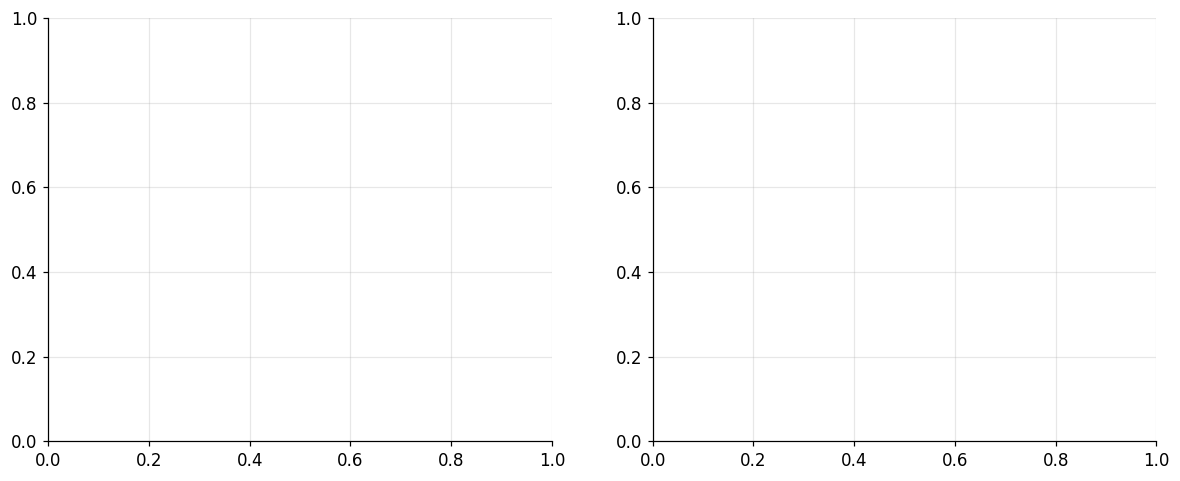

<Figure size 1430x550 with 0 Axes>

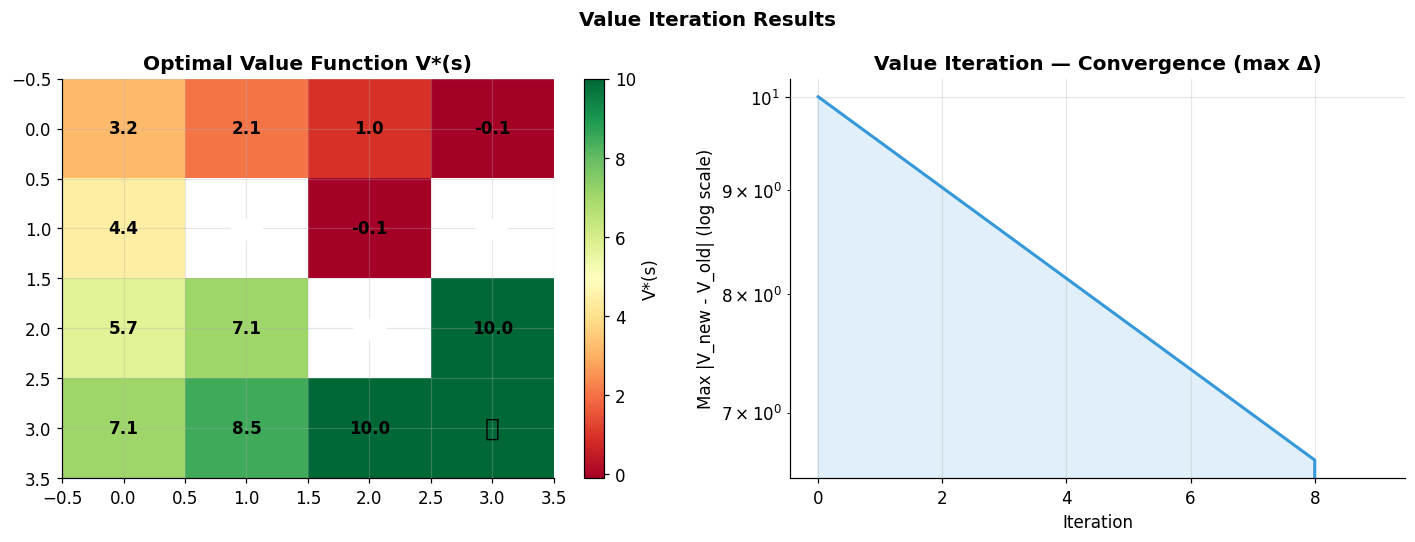

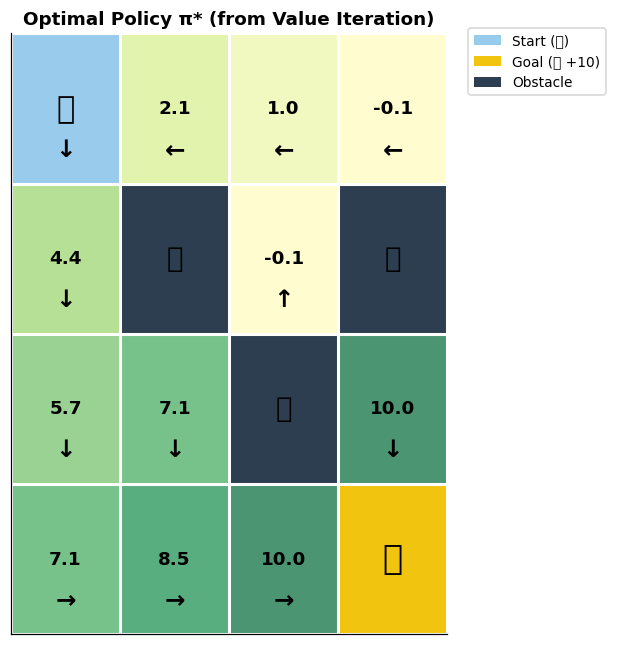

  ↓  ←  ←  ←
  ↓  █  ↑  █
  ↓  ↓  █  ↓
  →  →  →  🏆


In [6]:
# Visualise Value Function + Optimal Policy 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plt.figure(figsize=(13, 5))

# Value function heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Build value matrix
val_matrix = np.full((env_mdp.size, env_mdp.size), np.nan)
for r in range(env_mdp.size):
    for c in range(env_mdp.size):
        s = (r, c)
        if s not in env_mdp.obstacles:
            val_matrix[r, c] = V_star[s]

im = axes[0].imshow(val_matrix, cmap='RdYlGn', aspect='auto')
axes[0].set_title('Optimal Value Function V*(s)', fontweight='bold')
for r in range(env_mdp.size):
    for c in range(env_mdp.size):
        s = (r, c)
        if s in env_mdp.obstacles:
            axes[0].text(c, r, '██', ha='center', va='center',
                          fontsize=14, color='white')
        elif s == env_mdp.goal:
            axes[0].text(c, r, '🏆', ha='center', va='center', fontsize=16)
        else:
            axes[0].text(c, r, f'{V_star[s]:.1f}', ha='center', va='center',
                          fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='V*(s)')

# Convergence plot
axes[1].semilogy(deltas, color='#3498db', linewidth=2)
axes[1].fill_between(range(len(deltas)), deltas, alpha=0.15, color='#3498db')
axes[1].set_title('Value Iteration — Convergence (max Δ)', fontweight='bold')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Max |V_new - V_old| (log scale)')

plt.suptitle('Value Iteration Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Grid with optimal policy overlay
fig2 = plot_grid_world(env_mdp, title='Optimal Policy π* (from Value Iteration)',
                        values=V_star, policy=pi_star)
plt.show()


arrow_map = {0:'↑', 1:'↓', 2:'←', 3:'→'}
for r in range(env_mdp.size):
    row = []
    for c in range(env_mdp.size):
        s = (r, c)
        if s in env_mdp.obstacles: row.append('█')
        elif s == env_mdp.goal:    row.append('🏆')
        else:                       row.append(arrow_map.get(pi_star.get(s, 0), '?'))
    print('  ' + '  '.join(row))

---
## Section 4: OpenAI Gym / Gymnasium Environments

**Gymnasium** (the maintained successor to OpenAI Gym) provides a standardised API for RL environments.

### Standard Gym API
```python
env = gym.make('CartPole-v1')
obs, info = env.reset()

for step in range(200):
    action = env.action_space.sample()     # random policy
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    if done:
        obs, info = env.reset()

env.close()
```

### Classic Control Environments
| Environment | State Space | Action Space | Goal |
|---|---|---|---|
| **CartPole-v1** | 4 continuous (pos, vel, angle, ang vel) | 2 discrete (left/right) | Balance pole for 500 steps |
| **MountainCar-v0** | 2 continuous (pos, vel) | 3 discrete | Reach the hilltop |
| **FrozenLake-v1** | 16 discrete (4×4 grid) | 4 discrete | Cross ice without falling |
| **Acrobot-v1** | 6 continuous (joint angles & velocities) | 3 discrete | Swing end-effector above line |

In [7]:
# section 4 — Exploring Gymnasium Environments

import gymnasium as gym


env_cart = gym.make('CartPole-v1')
obs, info = env_cart.reset(seed=SEED)

print(' CartPole-v1 Environment')
print(f'   Observation space : {env_cart.observation_space}')
print(f'   Action space      : {env_cart.action_space}')
print(f'   Initial obs       : {obs.round(4)}')
print(f'   Obs meaning       : [cart_pos, cart_vel, pole_angle, pole_ang_vel]')


env_fl = gym.make('FrozenLake-v1', is_slippery=False)
obs_fl, _ = env_fl.reset(seed=SEED)
print('\n FrozenLake-v1 Environment')
print(f'   Observation space : {env_fl.observation_space}')
print(f'   Action space      : {env_fl.action_space}')


env_mc = gym.make('MountainCar-v0')
obs_mc, _ = env_mc.reset(seed=SEED)
print('\n  MountainCar-v0 Environment')
print(f'   Observation space : {env_mc.observation_space}')
print(f'   Action space      : {env_mc.action_space}')
print(f'   Obs bounds: min={env_mc.observation_space.low}, max={env_mc.observation_space.high}')

 CartPole-v1 Environment
   Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   Action space      : Discrete(2)
   Initial obs       : [ 0.0274 -0.0061  0.0359  0.0197]
   Obs meaning       : [cart_pos, cart_vel, pole_angle, pole_ang_vel]

 FrozenLake-v1 Environment
   Observation space : Discrete(16)
   Action space      : Discrete(4)

  MountainCar-v0 Environment
   Observation space : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
   Action space      : Discrete(3)
   Obs bounds: min=[-1.2  -0.07], max=[0.6  0.07]


In [8]:
def run_random_agent(env_name, n_episodes=50, seed=42):
    """Run a random agent and record episode rewards."""
    env = gym.make(env_name)
    episode_rewards = []
    episode_lengths = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        done = False

        while not done:
            action = env.action_space.sample()   # random action
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

    env.close()
    return episode_rewards, episode_lengths

envs_to_test = ['CartPole-v1', 'FrozenLake-v1', 'MountainCar-v0']
random_results = {}

for env_name in envs_to_test:
    rewards, lengths = run_random_agent(env_name, n_episodes=100)
    random_results[env_name] = {'rewards': rewards, 'lengths': lengths}
    print(f'  {env_name}: avg_reward={np.mean(rewards):.2f} ± {np.std(rewards):.2f}')

  CartPole-v1: avg_reward=23.72 ± 11.71
  FrozenLake-v1: avg_reward=0.03 ± 0.17
  MountainCar-v0: avg_reward=-200.00 ± 0.00


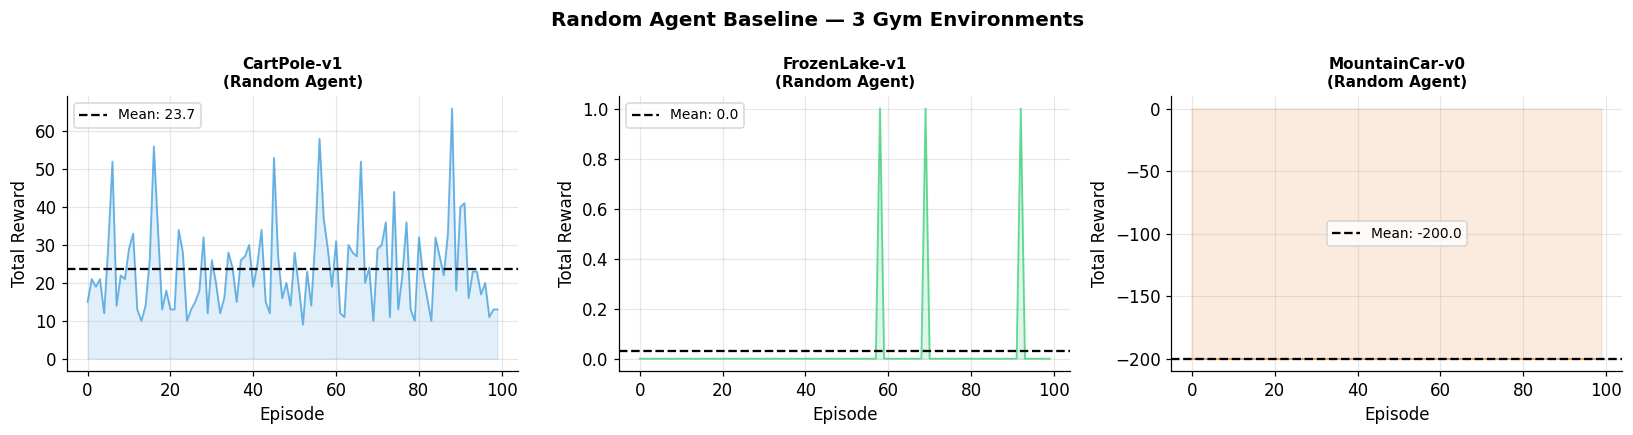

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
env_colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, env_name, color in zip(axes, envs_to_test, env_colors):
    rewards = random_results[env_name]['rewards']
    ax.plot(rewards, color=color, linewidth=1.2, alpha=0.7)
    ax.axhline(np.mean(rewards), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(rewards):.1f}')
    ax.fill_between(range(len(rewards)), rewards, alpha=0.15, color=color)
    ax.set_title(f'{env_name}\n(Random Agent)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(fontsize=9)

plt.suptitle('Random Agent Baseline — 3 Gym Environments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Q-Learning & Q-Tables

**Q-Learning** is a **model-free**, **off-policy** RL algorithm that learns the action-value function Q(s,a) directly from experience.

### Q-Learning Update Rule
```
Q(s, a) ← Q(s, a) + α · [r + γ · max_a' Q(s', a') − Q(s, a)]
                         └────────────────────────────────────┘
                                    TD Error (δ)
```

| Term | Meaning |
|---|---|
| `α` | Learning rate — how quickly to update |
| `r + γ · max Q(s',a')` | **TD Target** — what we want Q to equal |
| `Q(s,a)` | **TD Estimate** — current prediction |
| `TD Error δ` | Difference between target and estimate |

### ε-Greedy Exploration
```
With prob ε  → explore: take random action
With prob 1-ε → exploit: take argmax Q(s, a)
```
ε starts high (explore) and decays over time (exploit more).

In [10]:
# Section 5 — Q-Learning on FrozenLake

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


env_fl = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
n_states  = env_fl.observation_space.n    # 16
n_actions = env_fl.action_space.n         # 4


ALPHA       = 0.8      # learning rate
GAMMA       = 0.95     # discount factor
EPSILON     = 1.0      # initial exploration rate
EPS_MIN     = 0.01     # minimum epsilon
EPS_DECAY   = 0.995    # epsilon decay per episode
N_EPISODES  = 2000


Q_table = np.zeros((n_states, n_actions))


episode_rewards = []
episode_lengths = []
epsilon_history = []
q_value_history = []    # track convergence of a specific Q-value

for episode in range(N_EPISODES):
    state, _ = env_fl.reset(seed=episode)
    total_reward = 0
    steps = 0
    done = False

    while not done:
        # ε-greedy action selection
        if np.random.random() < EPSILON:
            action = env_fl.action_space.sample()      # explore
        else:
            action = np.argmax(Q_table[state])          # exploit

        # Take action
        next_state, reward, terminated, truncated, _ = env_fl.step(action)
        done = terminated or truncated

        # Q-Learning update
        td_target = reward + GAMMA * np.max(Q_table[next_state]) * (not done)
        td_error  = td_target - Q_table[state, action]
        Q_table[state, action] += ALPHA * td_error

        state = next_state
        total_reward += reward
        steps += 1

    # Decay epsilon
    EPSILON = max(EPS_MIN, EPSILON * EPS_DECAY)

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)
    epsilon_history.append(EPSILON)
    q_value_history.append(Q_table[0, 2])   # track Q(state=0, action=right)

env_fl.close()

# Results
win_rate = np.mean(episode_rewards[-200:]) * 100
print(f' Q-Learning training complete!')
print(f'   Win rate (last 200 eps): {win_rate:.1f}%')
print(f'   Final ε: {EPSILON:.4f}')

 Q-Learning training complete!
   Win rate (last 200 eps): 99.0%
   Final ε: 0.0100


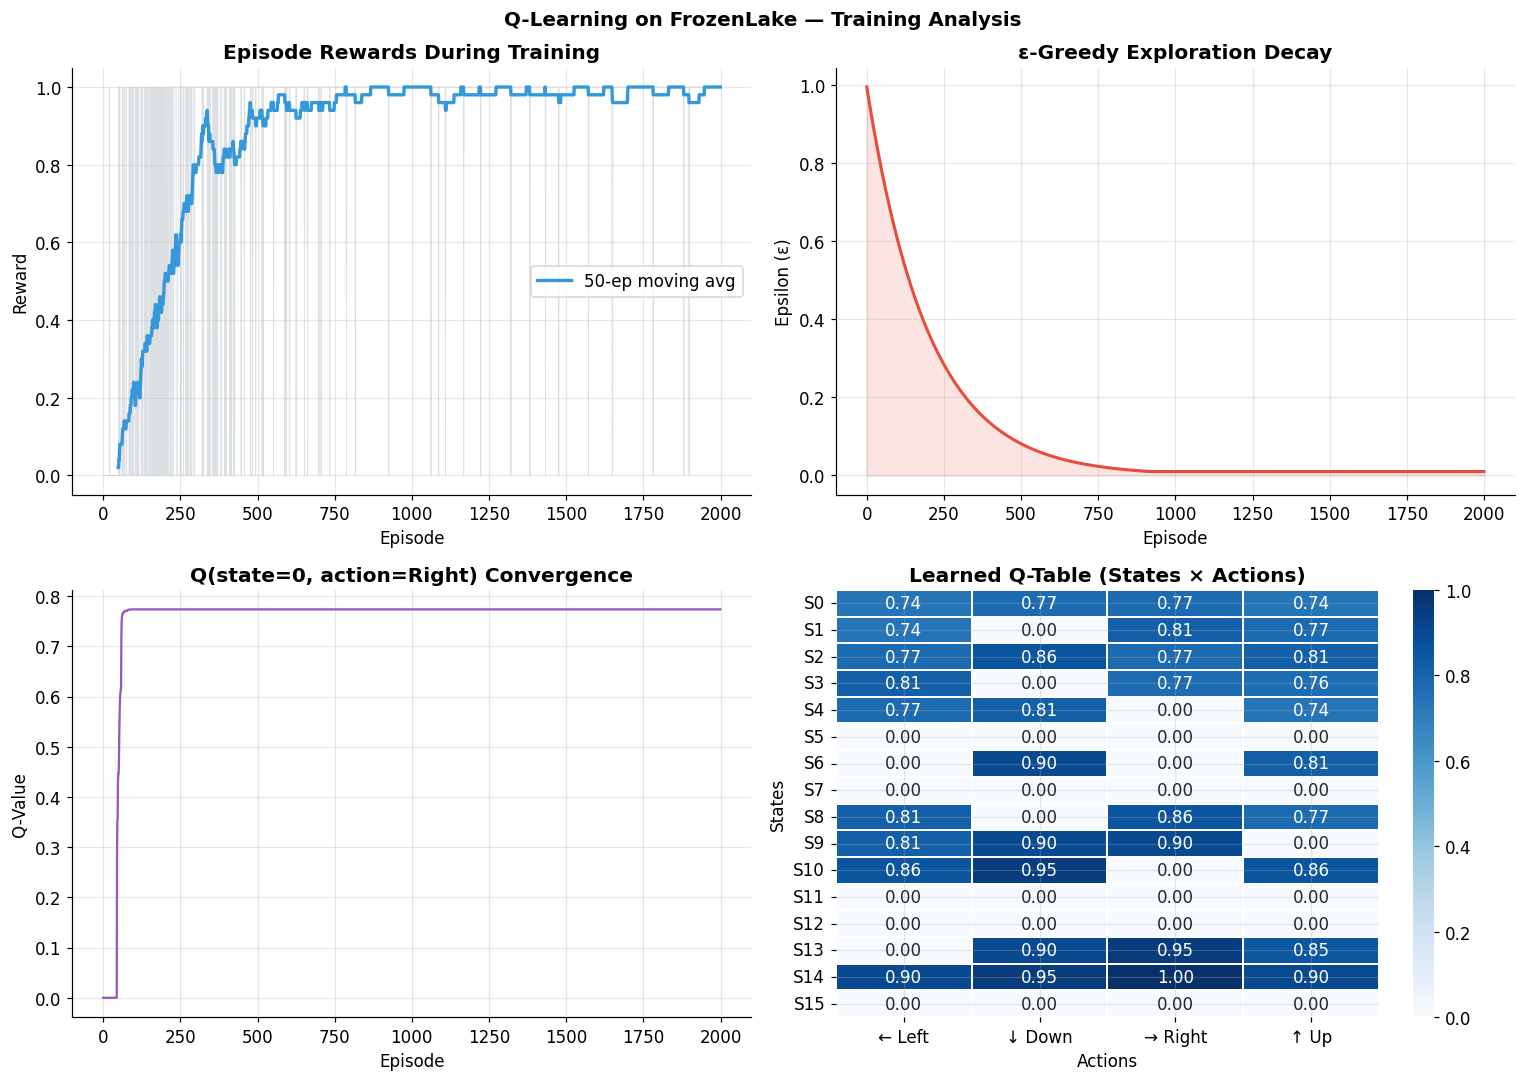

In [11]:
# Visualise Q-Learning Results 
window = 50
smoothed_rewards = pd.Series(episode_rewards).rolling(window).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Episode rewards
axes[0,0].plot(episode_rewards, color='#bdc3c7', linewidth=0.6, alpha=0.5)
axes[0,0].plot(smoothed_rewards, color='#3498db', linewidth=2.2, label=f'{window}-ep moving avg')
axes[0,0].set_title('Episode Rewards During Training', fontweight='bold')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Reward')
axes[0,0].legend()

# Epsilon decay
axes[0,1].plot(epsilon_history, color='#e74c3c', linewidth=2)
axes[0,1].fill_between(range(len(epsilon_history)), epsilon_history, alpha=0.15, color='#e74c3c')
axes[0,1].set_title('ε-Greedy Exploration Decay', fontweight='bold')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('Epsilon (ε)')

# Q-value convergence
axes[1,0].plot(q_value_history, color='#9b59b6', linewidth=1.5)
axes[1,0].set_title('Q(state=0, action=Right) Convergence', fontweight='bold')
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('Q-Value')

# Q-table heatmap
action_labels = ['← Left', '↓ Down', '→ Right', '↑ Up']
sns.heatmap(Q_table, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=action_labels,
            yticklabels=[f'S{i}' for i in range(n_states)],
            ax=axes[1,1], linewidths=0.3)
axes[1,1].set_title('Learned Q-Table (States × Actions)', fontweight='bold')
axes[1,1].set_xlabel('Actions')
axes[1,1].set_ylabel('States')

plt.suptitle('Q-Learning on FrozenLake — Training Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

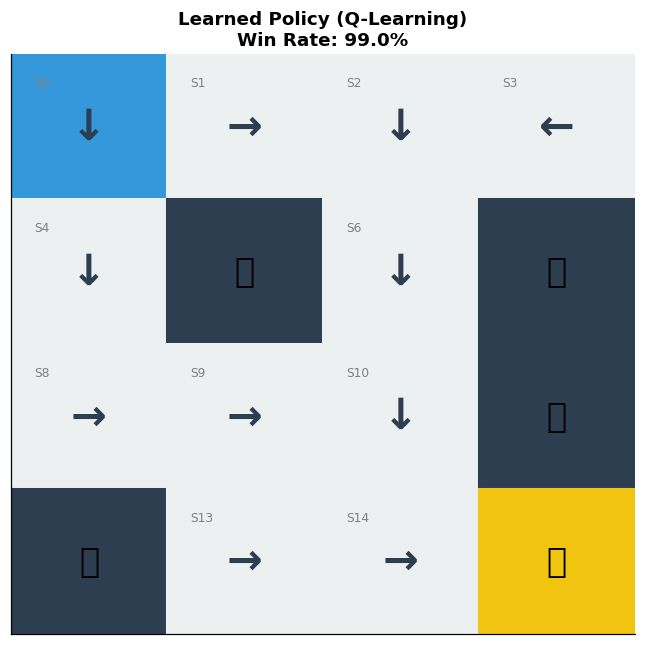

In [12]:
policy_symbols = ['←', '↓', '→', '↑']
# FrozenLake map: S=start, F=frozen, H=hole, G=goal
fl_map = [
    'SFFF',
    'FHFH',
    'FFFH',
    'HFFG'
]

fig, ax = plt.subplots(figsize=(6, 6))
cell_colors = {'S': '#3498db', 'F': '#ecf0f1', 'H': '#2c3e50', 'G': '#f1c40f'}
cell_labels = {'S': 'Start', 'H': 'Hole\n(💀)', 'G': 'Goal\n(🏆)'}

for r in range(4):
    for c in range(4):
        cell_type = fl_map[r][c]
        color = cell_colors[cell_type]
        ax.add_patch(plt.Rectangle((c, 3-r), 1, 1, color=color,
                                    edgecolor='white', linewidth=2, zorder=1))
        state_idx = r * 4 + c
        best_action = np.argmax(Q_table[state_idx])

        if cell_type in ('H', 'G'):
            label = '💀' if cell_type == 'H' else '🏆'
            ax.text(c+0.5, 3-r+0.5, label, ha='center', va='center', fontsize=22, zorder=3)
        else:
            ax.text(c+0.5, 3-r+0.5, policy_symbols[best_action],
                    ha='center', va='center', fontsize=28, fontweight='bold',
                    color='#2c3e50', zorder=3)
            ax.text(c+0.15, 3-r+0.85, f'S{state_idx}', ha='left', va='top',
                    fontsize=8, color='gray', zorder=3)

ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Learned Policy (Q-Learning)\nWin Rate: {win_rate:.1f}%',
              fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 6: Deep Q-Networks (DQN)

Q-tables fail when the **state space is continuous or very large** (CartPole has infinitely many states). **DQN** replaces the Q-table with a **neural network** that approximates Q(s, a; θ).

### DQN Innovations (Mnih et al., 2015)

| Innovation | Purpose |
|---|---|
| **Experience Replay** | Store transitions in a replay buffer; sample random mini-batches → breaks temporal correlation |
| **Target Network** | Separate network for computing TD targets; updated slowly → stabilises training |
| **Huber Loss** | Robust to outliers in TD errors |

### DQN Loss Function
```
L(θ) = E[(r + γ · max_a' Q(s', a'; θ⁻) − Q(s, a; θ))²]
                              └────┘
                          Target network (θ⁻ updated every C steps)
```

### Architecture
```
State s (4 values) → [FC 64] → ReLU → [FC 64] → ReLU → [FC n_actions]
                                                          └── Q(s,a) for each action
```

In [13]:
# Section 6 — Deep Q-Network (DQN) for CartPole-v1

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random


class ReplayBuffer:
    """Experience replay buffer stores (s, a, r, s', done) tuples."""

    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """Fully-connected Q-network: state → Q-values for each action."""

    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)



class DQNAgent:
    def __init__(self, state_dim, action_dim,
                 lr=1e-3, gamma=0.99, epsilon=1.0,
                 eps_min=0.01, eps_decay=0.995,
                 buffer_size=10_000, batch_size=64,
                 target_update_freq=100):

        self.action_dim       = action_dim
        self.gamma            = gamma
        self.epsilon          = epsilon
        self.eps_min          = eps_min
        self.eps_decay        = eps_decay
        self.batch_size       = batch_size
        self.target_update_freq = target_update_freq
        self.learn_step_counter = 0

        # Online network (trained every step)
        self.q_net      = QNetwork(state_dim, action_dim)
        # Target network (updated slowly — stabilises training)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_size)

    def select_action(self, state):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            q_vals  = self.q_net(state_t)
            return q_vals.argmax().item()

    def learn(self):
        """Sample mini-batch and perform one gradient update."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = \
            self.buffer.sample(self.batch_size)

        # Current Q-values: Q(s, a; θ)
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q-values: r + γ · max_a' Q(s', a'; θ⁻)
        with torch.no_grad():
            next_q   = self.target_net(next_states).max(1)[0]
            td_target = rewards + self.gamma * next_q * (1 - dones)

        # Huber loss (smooth L1) — robust to outliers
        loss = F.smooth_l1_loss(q_values, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping — prevents exploding gradients
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10)
        self.optimizer.step()

        # Update target network periodically
        self.learn_step_counter += 1
        if self.learn_step_counter % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)


# Check architecture
agent = DQNAgent(state_dim=4, action_dim=2)
total_params = sum(p.numel() for p in agent.q_net.parameters())
print(' DQN Agent Created')
print(f'   Q-Network: {agent.q_net}')
print(f'   Parameters: {total_params:,}')

 DQN Agent Created
   Q-Network: QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
   Parameters: 17,410


In [14]:

env_dqn    = gym.make('CartPole-v1')
agent_dqn  = DQNAgent(
    state_dim=4, action_dim=2,
    lr=5e-4, gamma=0.99,
    epsilon=1.0, eps_min=0.01, eps_decay=0.997,
    buffer_size=10_000, batch_size=64,
    target_update_freq=50
)

N_EPISODES_DQN  = 300
dqn_rewards     = []
dqn_losses      = []
dqn_epsilons    = []

SOLVED_THRESHOLD = 195   # CartPole is 'solved' at avg reward ≥ 195 over 100 eps


print(f'   Target: avg reward ≥ {SOLVED_THRESHOLD} over 100 episodes')
print('─' * 55)

for episode in range(N_EPISODES_DQN):
    state, _ = env_dqn.reset(seed=episode)
    total_reward = 0
    ep_losses    = []
    done = False

    while not done:
        action = agent_dqn.select_action(state)
        next_state, reward, terminated, truncated, _ = env_dqn.step(action)
        done = terminated or truncated

        # Store experience in replay buffer
        agent_dqn.buffer.push(state, action, reward, next_state, float(done))

        # Learn from replay buffer
        loss = agent_dqn.learn()
        if loss is not None:
            ep_losses.append(loss)

        state = next_state
        total_reward += reward

    agent_dqn.decay_epsilon()
    dqn_rewards.append(total_reward)
    dqn_epsilons.append(agent_dqn.epsilon)
    if ep_losses:
        dqn_losses.append(np.mean(ep_losses))

    if (episode + 1) % 50 == 0:
        avg_100 = np.mean(dqn_rewards[-100:])
        print(f'  Episode {episode+1:3d}/{N_EPISODES_DQN} | '
              f'Avg(100): {avg_100:6.1f} | '
              f'ε: {agent_dqn.epsilon:.3f}')

env_dqn.close()

final_avg = np.mean(dqn_rewards[-100:])
solved    = ' SOLVED!' if final_avg >= SOLVED_THRESHOLD else '⏳ Not solved yet'
print(f'\nFinal 100-episode avg: {final_avg:.1f}  {solved}')

   Target: avg reward ≥ 195 over 100 episodes
───────────────────────────────────────────────────────
  Episode  50/300 | Avg(100):   24.1 | ε: 0.861
  Episode 100/300 | Avg(100):   28.6 | ε: 0.740
  Episode 150/300 | Avg(100):   39.5 | ε: 0.637
  Episode 200/300 | Avg(100):   43.4 | ε: 0.548
  Episode 250/300 | Avg(100):   43.2 | ε: 0.472
  Episode 300/300 | Avg(100):   49.6 | ε: 0.406

Final 100-episode avg: 49.6  ⏳ Not solved yet


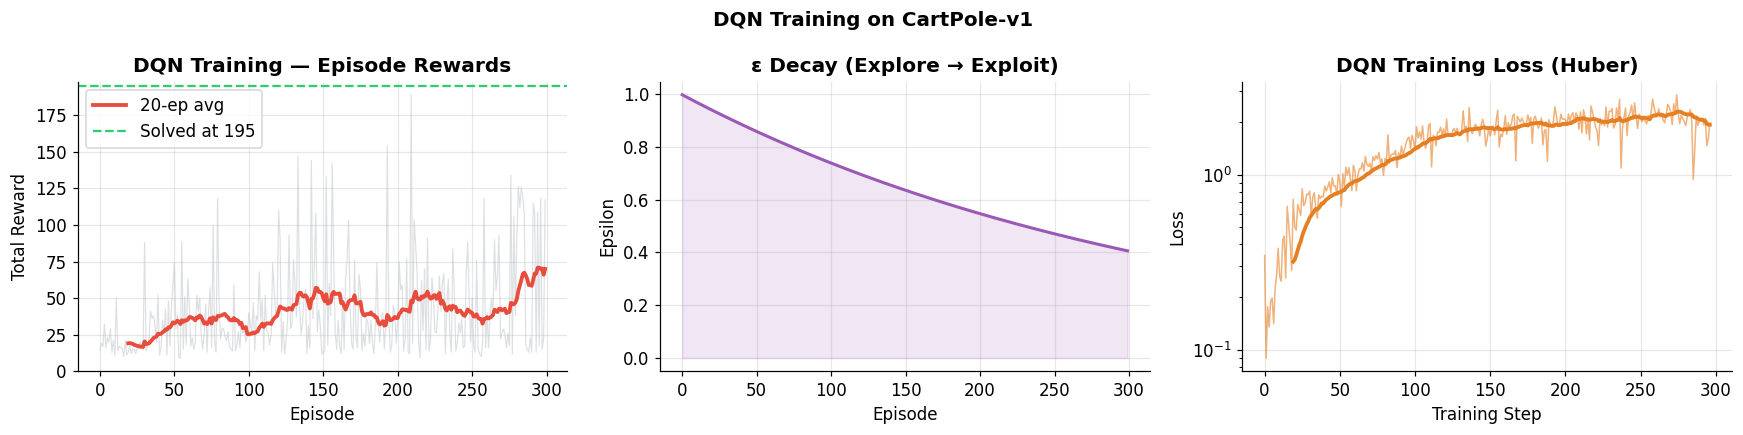


 Evaluation (20 episodes, ε=0):
   Avg reward: 112.3 ± 4.9
   Min: 102  Max: 123


In [15]:
# ── Visualise DQN Training ────────────────────────────────────
window_dqn = 20
smoothed_dqn = pd.Series(dqn_rewards).rolling(window_dqn).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rewards
axes[0].plot(dqn_rewards, color='#bdc3c7', linewidth=0.8, alpha=0.5)
axes[0].plot(smoothed_dqn, color='#e74c3c', linewidth=2.5,
              label=f'{window_dqn}-ep avg')
axes[0].axhline(SOLVED_THRESHOLD, color='#2ecc71', linestyle='--',
                 linewidth=1.5, label=f'Solved at {SOLVED_THRESHOLD}')
axes[0].set_title('DQN Training — Episode Rewards', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()

# Epsilon
axes[1].plot(dqn_epsilons, color='#9b59b6', linewidth=2)
axes[1].fill_between(range(len(dqn_epsilons)), dqn_epsilons, alpha=0.15, color='#9b59b6')
axes[1].set_title('ε Decay (Explore → Exploit)', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Epsilon')

# Loss
if dqn_losses:
    axes[2].plot(dqn_losses, color='#e67e22', linewidth=1, alpha=0.6)
    axes[2].plot(pd.Series(dqn_losses).rolling(20).mean(),
                  color='#e67e22', linewidth=2.5)
    axes[2].set_title('DQN Training Loss (Huber)', fontweight='bold')
    axes[2].set_xlabel('Training Step')
    axes[2].set_ylabel('Loss')
    axes[2].set_yscale('log')

plt.suptitle('DQN Training on CartPole-v1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate trained agent
env_eval = gym.make('CartPole-v1')
agent_dqn.epsilon = 0.0    # pure exploitation
eval_rewards = []

for ep in range(20):
    state, _ = env_eval.reset(seed=1000 + ep)
    total_r  = 0
    done     = False
    while not done:
        action = agent_dqn.select_action(state)
        state, r, term, trunc, _ = env_eval.step(action)
        done = term or trunc
        total_r += r
    eval_rewards.append(total_r)
env_eval.close()

print(f'\n Evaluation (20 episodes, ε=0):')
print(f'   Avg reward: {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}')
print(f'   Min: {min(eval_rewards):.0f}  Max: {max(eval_rewards):.0f}')

---
## Section 7: Policy Gradient Methods (REINFORCE)

Instead of learning a value function and deriving a policy, **Policy Gradient** methods **directly optimise the policy** π(a|s; θ) by gradient ascent on expected return.

### Policy Gradient Theorem
```
∇_θ J(θ) = E_π [ ∇_θ log π(a|s; θ) · G_t ]
```
where `G_t` is the discounted return from step `t`.

### REINFORCE Algorithm (Monte Carlo Policy Gradient)
```
For each episode:
  1. Run full episode with current policy → collect (s, a, r) trajectory
  2. Compute returns G_t = Σ γᵏ r_{t+k}
  3. Normalise G_t (reduce variance)
  4. Compute loss = -Σ log π(a_t|s_t) · G_t
  5. Gradient ascent: θ ← θ + α ∇_θ J
```

| | Value-Based (DQN) | Policy-Based (REINFORCE) |
|---|---|---|
| **What it learns** | Q(s,a) → derive policy | π(a|s) directly |
| **Action spaces** | Discrete only | Discrete & Continuous |
| **Variance** | Lower | Higher (uses full return) |
| **Stability** | More stable | Can be unstable |

In [16]:
# Section 7 — REINFORCE Policy Gradient on CartPole-v1
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# ── Policy Network ────────────────────────────────────────────
class PolicyNetwork(nn.Module):
    """
    Stochastic policy: outputs a probability distribution over actions.
    π(a | s; θ)
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return F.softmax(logits, dim=-1)   # probability over actions



class REINFORCEAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.policy  = PolicyNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma   = gamma
        # Episode memory
        self.log_probs = []
        self.rewards   = []

    def select_action(self, state):
        """Sample action from policy distribution — stochastic!"""
        state_t  = torch.FloatTensor(state).unsqueeze(0)
        probs    = self.policy(state_t)
        dist     = Categorical(probs)
        action   = dist.sample()
        self.log_probs.append(dist.log_prob(action))
        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def compute_returns(self):
        """Compute discounted returns G_t for the episode."""
        returns = []
        G = 0
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        # Normalise returns — reduces variance significantly
        returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        return returns

    def update(self):
        """Perform REINFORCE gradient update."""
        returns    = self.compute_returns()
        log_probs  = torch.stack(self.log_probs)

        # Policy gradient loss: -E[log π(a|s) · G_t]
        # Negative because we do gradient ASCENT via gradient descent
        policy_loss = -(log_probs * returns).sum()

        self.optimizer.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()

        # Clear episode memory
        self.log_probs.clear()
        self.rewards.clear()
        return policy_loss.item()



env_pg     = gym.make('CartPole-v1')
pg_agent   = REINFORCEAgent(state_dim=4, action_dim=2, lr=1e-3, gamma=0.99)

N_EPISODES_PG = 500
pg_rewards    = []
pg_losses     = []



for episode in range(N_EPISODES_PG):
    state, _ = env_pg.reset(seed=episode)
    total_reward = 0
    done = False

    # Collect full episode trajectory
    while not done:
        action = pg_agent.select_action(state)
        state, reward, terminated, truncated, _ = env_pg.step(action)
        done = terminated or truncated
        pg_agent.store_reward(reward)
        total_reward += reward

    # Update policy after each full episode
    loss = pg_agent.update()
    pg_rewards.append(total_reward)
    pg_losses.append(loss)

    if (episode + 1) % 100 == 0:
        avg = np.mean(pg_rewards[-100:])
        print(f'  Episode {episode+1}/{N_EPISODES_PG} | Avg(100): {avg:.1f}')

env_pg.close()
print(f'\nFinal 100-ep avg: {np.mean(pg_rewards[-100:]):.1f}')

  Episode 100/500 | Avg(100): 15.5
  Episode 200/500 | Avg(100): 13.0
  Episode 300/500 | Avg(100): 12.7
  Episode 400/500 | Avg(100): 11.3
  Episode 500/500 | Avg(100): 10.1

Final 100-ep avg: 10.1


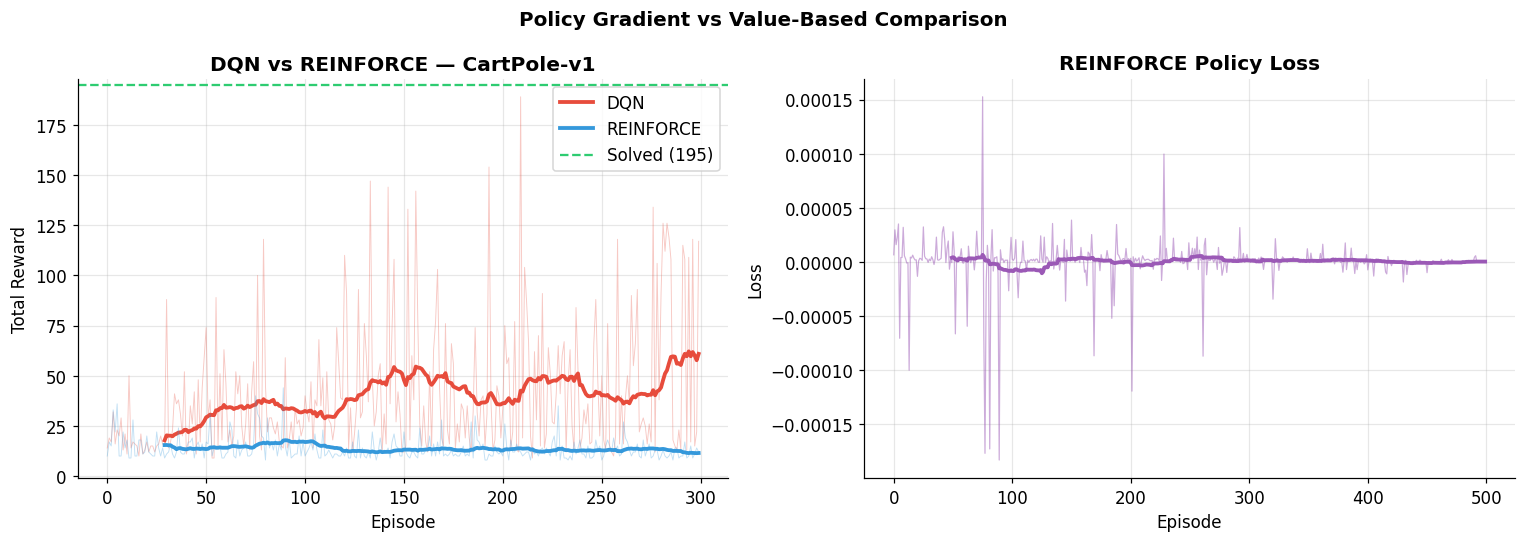

In [17]:
window = 30
dqn_smooth = pd.Series(dqn_rewards).rolling(window).mean()
pg_smooth  = pd.Series(pg_rewards[:N_EPISODES_DQN]).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Side-by-side comparison
x_dqn = range(len(dqn_rewards))
axes[0].plot(dqn_rewards, color='#e74c3c', linewidth=0.6, alpha=0.3)
axes[0].plot(dqn_smooth,  color='#e74c3c', linewidth=2.5, label='DQN')
x_pg = range(len(pg_rewards[:N_EPISODES_DQN]))
axes[0].plot(pg_rewards[:N_EPISODES_DQN], color='#3498db', linewidth=0.6, alpha=0.3)
axes[0].plot(pg_smooth,   color='#3498db', linewidth=2.5, label='REINFORCE')
axes[0].axhline(195, color='#2ecc71', linestyle='--', linewidth=1.5, label='Solved (195)')
axes[0].set_title('DQN vs REINFORCE — CartPole-v1', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()

# REINFORCE loss
axes[1].plot(pg_losses, color='#9b59b6', linewidth=0.8, alpha=0.5)
axes[1].plot(pd.Series(pg_losses).rolling(50).mean(), color='#9b59b6', linewidth=2.5)
axes[1].set_title('REINFORCE Policy Loss', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')

plt.suptitle('Policy Gradient vs Value-Based Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8: Actor-Critic Methods

**Actor-Critic** methods combine the best of both worlds:
- **Actor** (policy network `π(a|s;θ)`) : decides which action to take
- **Critic** (value network `V(s;w)`) : evaluates how good the current state is

### Why Actor-Critic?
- REINFORCE has **high variance** because it uses full episode returns G_t
- The Critic provides a **baseline** to reduce variance: use **Advantage A(s,a)** instead of G_t

```
Advantage:  A(s, a) = Q(s, a) - V(s)
                    ≈ r + γV(s') - V(s)   (TD advantage estimate)

Actor loss:  -log π(a|s) · A(s,a)
Critic loss:  (r + γV(s') - V(s))²
```

### A2C Architecture
```
         ┌────────────────────────────┐
         │        Shared Backbone     │
         │   [FC 128] → ReLU          │
         └────────────────────────────┘
              ↙                  ↘
   [Actor Head]             [Critic Head]
   [FC → n_actions]         [FC → 1]
   softmax → π(a|s)         scalar → V(s)
```

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

# Actor-Critic Network (shared backbone)
class ActorCriticNetwork(nn.Module):
    """
    Shared-backbone Actor-Critic.
    Actor  → π(a|s)  (policy)
    Critic → V(s)    (state value)
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        # Shared feature extractor
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        self.actor  = nn.Linear(hidden, action_dim)   # policy head
        self.critic = nn.Linear(hidden, 1)            # value head

    def forward(self, x):
        features = self.shared(x)
        action_probs = F.softmax(self.actor(features), dim=-1)
        state_value  = self.critic(features)
        return action_probs, state_value


# A2C Agent
class A2CAgent:
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99,
                 value_coef=0.5, entropy_coef=0.01):
        self.gamma       = gamma
        self.value_coef  = value_coef    # weight of critic loss
        self.entropy_coef= entropy_coef  # entropy bonus — encourages exploration

        self.ac_net    = ActorCriticNetwork(state_dim, action_dim)
        self.optimizer = torch.optim.Adam(self.ac_net.parameters(), lr=lr)

        self.log_probs  = []
        self.values     = []
        self.rewards    = []
        self.entropies  = []

    def select_action(self, state):
        state_t      = torch.FloatTensor(state).unsqueeze(0)
        probs, value = self.ac_net(state_t)
        dist         = Categorical(probs)
        action       = dist.sample()

        self.log_probs.append(dist.log_prob(action))
        self.values.append(value)
        self.entropies.append(dist.entropy())
        return action.item()

    def update(self, next_state, done):
        # Bootstrap value for last state
        if done:
            next_value = torch.tensor([[0.0]])
        else:
            next_state_t = torch.FloatTensor(next_state).unsqueeze(0)
            _, next_value = self.ac_net(next_state_t)

        # Compute returns and advantages
        returns = []
        G = next_value.item()
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)

        returns   = torch.FloatTensor(returns)
        values    = torch.cat(self.values).squeeze()
        log_probs = torch.stack(self.log_probs)
        entropies = torch.stack(self.entropies)

        # Advantage = Return - Baseline(Value)
        advantages = returns - values.detach()
        # Normalise advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Losses
        actor_loss  = -(log_probs * advantages).mean()
        critic_loss = F.mse_loss(values, returns)
        entropy_loss = -entropies.mean()   # entropy bonus (negative = maximise entropy)

        # Combined loss: actor + weighted critic + entropy bonus
        total_loss = (actor_loss
                      + self.value_coef * critic_loss
                      + self.entropy_coef * entropy_loss)

        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(self.ac_net.parameters(), 0.5)
        self.optimizer.step()

        self.log_probs.clear()
        self.values.clear()
        self.rewards.clear()
        self.entropies.clear()

        return {
            'total_loss':  total_loss.item(),
            'actor_loss':  actor_loss.item(),
            'critic_loss': critic_loss.item()
        }


# Training A2C
env_a2c  = gym.make('CartPole-v1')
a2c_agent = A2CAgent(state_dim=4, action_dim=2, lr=3e-4,
                     gamma=0.99, value_coef=0.5, entropy_coef=0.01)

N_EPISODES_A2C = 400
a2c_rewards    = []
a2c_actor_losses  = []
a2c_critic_losses = []



for episode in range(N_EPISODES_A2C):
    state, _ = env_a2c.reset(seed=episode)
    total_reward = 0
    done = False
    ep_losses = []

    while not done:
        action = a2c_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env_a2c.step(action)
        done = terminated or truncated
        a2c_agent.rewards.append(reward)
        total_reward += reward
        state = next_state

    losses = a2c_agent.update(state, done)
    a2c_rewards.append(total_reward)
    a2c_actor_losses.append(losses['actor_loss'])
    a2c_critic_losses.append(losses['critic_loss'])

    if (episode + 1) % 100 == 0:
        avg = np.mean(a2c_rewards[-100:])
        print(f'  Episode {episode+1}/{N_EPISODES_A2C} | Avg(100): {avg:.1f}')

env_a2c.close()
print(f'\nFinal 100-ep avg: {np.mean(a2c_rewards[-100:]):.1f}')

  Episode 100/400 | Avg(100): 21.4
  Episode 200/400 | Avg(100): 21.0
  Episode 300/400 | Avg(100): 22.2
  Episode 400/400 | Avg(100): 21.5

Final 100-ep avg: 21.5


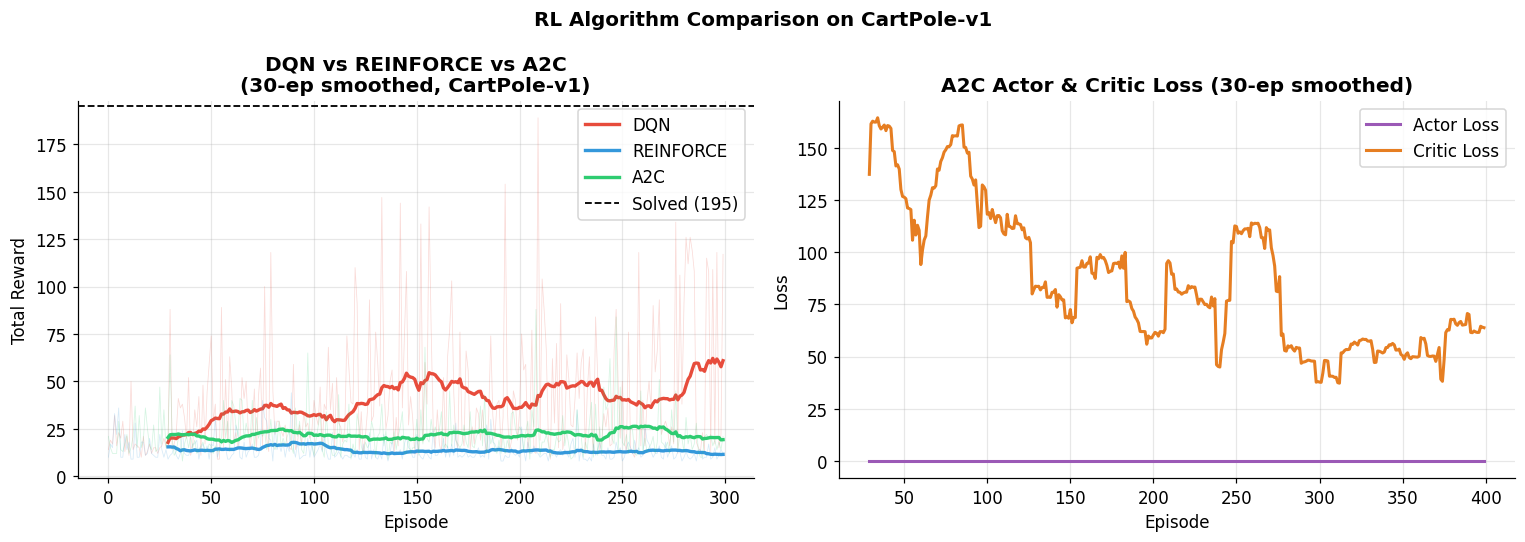

In [19]:
win = 30
n   = min(N_EPISODES_DQN, N_EPISODES_PG, N_EPISODES_A2C)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

algo_data = [
    ('DQN',       dqn_rewards[:n],    '#e74c3c'),
    ('REINFORCE', pg_rewards[:n],     '#3498db'),
    ('A2C',       a2c_rewards[:n],    '#2ecc71'),
]

for name, rews, color in algo_data:
    s = pd.Series(rews).rolling(win).mean()
    axes[0].plot(rews,  color=color, linewidth=0.5, alpha=0.2)
    axes[0].plot(s,     color=color, linewidth=2.2, label=name)

axes[0].axhline(195, color='black', linestyle='--', linewidth=1.2, label='Solved (195)')
axes[0].set_title(f'DQN vs REINFORCE vs A2C\n({win}-ep smoothed, CartPole-v1)', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()

# Actor vs Critic loss for A2C
axes[1].plot(pd.Series(a2c_actor_losses).rolling(30).mean(),
              color='#9b59b6', linewidth=2, label='Actor Loss')
axes[1].plot(pd.Series(a2c_critic_losses).rolling(30).mean(),
              color='#e67e22', linewidth=2, label='Critic Loss')
axes[1].set_title('A2C Actor & Critic Loss (30-ep smoothed)', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('RL Algorithm Comparison on CartPole-v1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 9: Reward Shaping & Exploration Strategies

### Reward Shaping
Real-world rewards are often **sparse** (only at the very end) or **delayed**. Reward shaping adds auxiliary rewards to guide learning.

```python
# Example: MountainCar has reward=-1 every step, +0 at goal
# Shaped reward adds a bonus for height gained:
shaped_reward = reward + 300 * (abs(next_state[1]))  # velocity bonus
```

### Exploration Strategies
| Strategy | Description | Best For |
|---|---|---|
| **ε-greedy** | Random action with prob ε | Simple, widely used |
| **ε-greedy decay** | ε decreases over training | Most common in DQN |
| **Boltzmann / Softmax** | Sample action ∝ exp(Q/τ) | Smooth exploration |
| **UCB (Upper Confidence Bound)** | Prefer least-visited state-action pairs | Bandits |
| **Noisy Networks** | Add noise to network weights | Better DQN exploration |
| **Intrinsic Motivation** | Reward curiosity / novelty | Sparse reward problems |

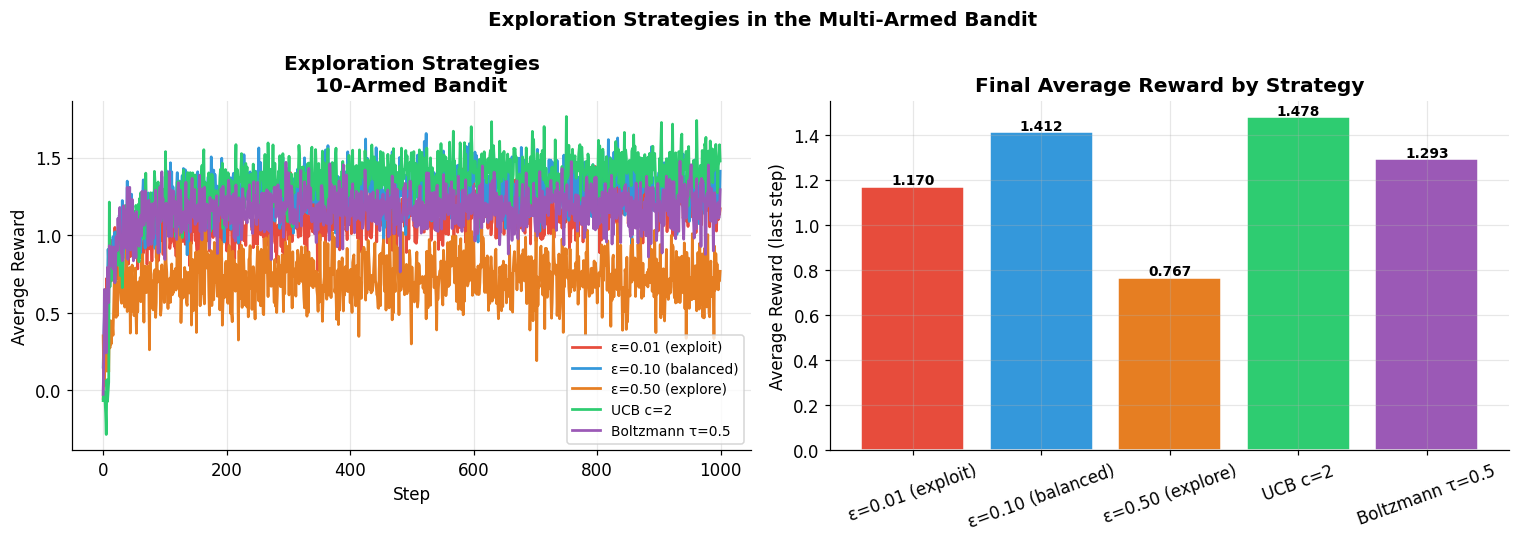

In [20]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(SEED)
N_ARMS    = 10
N_STEPS   = 1000
N_RUNS    = 100    # average over multiple runs


def epsilon_greedy(q_true, epsilon, n_steps):
    n_arms = len(q_true)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []
    for t in range(n_steps):
        a = np.random.randint(n_arms) if np.random.random() < epsilon \
            else np.argmax(Q)
        r = np.random.normal(q_true[a], 1)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards.append(r)
    return rewards

def ucb_bandit(q_true, c, n_steps):
    n_arms = len(q_true)
    Q = np.zeros(n_arms)
    N = np.ones(n_arms) * 1e-5   # avoid log(0)
    rewards = []
    for t in range(1, n_steps+1):
        ucb_vals = Q + c * np.sqrt(np.log(t) / N)
        a = np.argmax(ucb_vals)
        r = np.random.normal(q_true[a], 1)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards.append(r)
    return rewards

def boltzmann_bandit(q_true, tau, n_steps):
    n_arms = len(q_true)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []
    for t in range(n_steps):
        exp_q = np.exp(Q / tau)
        probs = exp_q / exp_q.sum()
        a = np.random.choice(n_arms, p=probs)
        r = np.random.normal(q_true[a], 1)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards.append(r)
    return rewards

#  Average over multiple runs 
strategies = {
    'ε=0.01 (exploit)':   lambda q: epsilon_greedy(q, 0.01, N_STEPS),
    'ε=0.10 (balanced)':  lambda q: epsilon_greedy(q, 0.10, N_STEPS),
    'ε=0.50 (explore)':   lambda q: epsilon_greedy(q, 0.50, N_STEPS),
    'UCB c=2':            lambda q: ucb_bandit(q, 2.0, N_STEPS),
    'Boltzmann τ=0.5':    lambda q: boltzmann_bandit(q, 0.5, N_STEPS),
}

avg_rewards = {name: np.zeros(N_STEPS) for name in strategies}

for run in range(N_RUNS):
    q_true = np.random.normal(0, 1, N_ARMS)
    for name, strategy in strategies.items():
        r = strategy(q_true)
        avg_rewards[name] += np.array(r) / N_RUNS

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for (name, rewards), color in zip(avg_rewards.items(), colors):
    axes[0].plot(rewards, color=color, linewidth=1.8, label=name)

axes[0].set_title('Exploration Strategies\n10-Armed Bandit', fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Average Reward')
axes[0].legend(fontsize=9)

# Final rewards bar chart
final_rewards = {name: avg_rewards[name][-1] for name in strategies}
bars = axes[1].bar(list(final_rewards.keys()), list(final_rewards.values()),
                    color=colors, edgecolor='white')
axes[1].set_title('Final Average Reward by Strategy', fontweight='bold')
axes[1].set_ylabel('Average Reward (last step)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, final_rewards.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Exploration Strategies in the Multi-Armed Bandit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

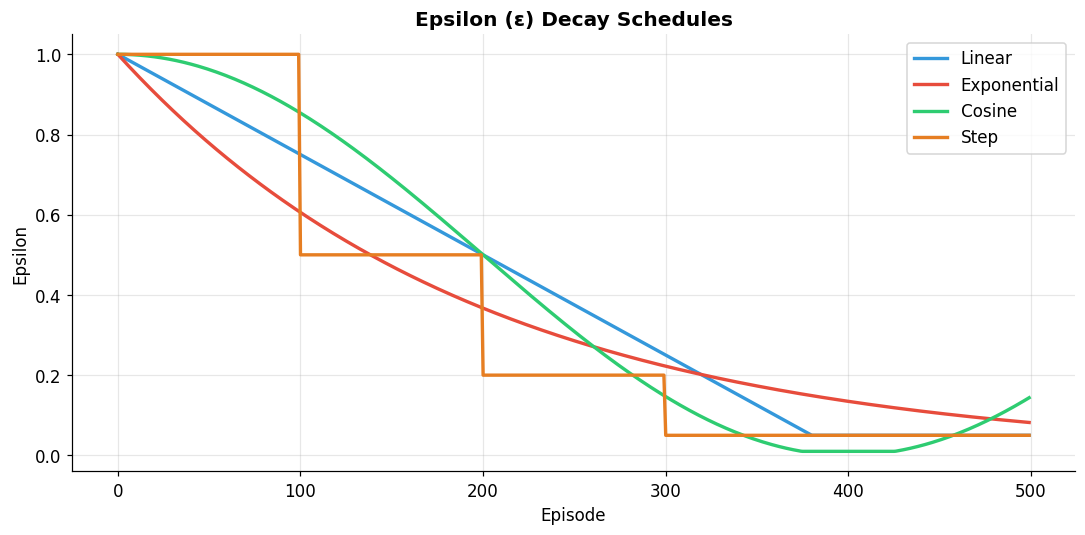

In [21]:
#  ε Decay Schedules 
episodes = np.arange(0, 500)

# Different decay approaches
linear_decay      = np.maximum(1.0 - episodes / 400, 0.05)
exponential_decay = np.maximum(1.0 * (0.995 ** episodes), 0.01)
cosine_decay      = np.maximum(0.5 * (1 + np.cos(np.pi * episodes / 400)), 0.01)
step_decay        = np.where(episodes < 100, 1.0,
                    np.where(episodes < 200, 0.5,
                    np.where(episodes < 300, 0.2, 0.05)))

fig, ax = plt.subplots(figsize=(10, 5))
for label, sched, color in [
    ('Linear',      linear_decay,      '#3498db'),
    ('Exponential', exponential_decay, '#e74c3c'),
    ('Cosine',      cosine_decay,      '#2ecc71'),
    ('Step',        step_decay,        '#e67e22'),
]:
    ax.plot(episodes, sched, linewidth=2.2, label=label, color=color)

ax.set_title('Epsilon (ε) Decay Schedules', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 10: 🚀 Mini Project | Full DQN Pipeline

### Objective
Build a **complete, production-quality DQN pipeline** that:
1. Sets up the environment with proper wrappers
2. Implements **Double DQN** (reduces overestimation bias)
3. Trains with a comprehensive logging system
4. Evaluates the trained agent
5. Visualises the agent's learned Q-values
6. Generates a final performance report

### Double DQN Improvement
Standard DQN overestimates Q-values because it uses the same network for both **selecting** and **evaluating** actions.

**Standard DQN target:**
```
y = r + γ · max_a' Q_target(s', a'; θ⁻)
```

**Double DQN target:**
```
a* = argmax_a Q_online(s', a; θ)         ← online net selects action
y  = r + γ · Q_target(s', a*; θ⁻)       ← target net evaluates it
```

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import random, time


class DuelingQNetwork(nn.Module):
    """
    Dueling DQN architecture:
    Q(s,a) = V(s) + A(s,a) - mean_a A(s,a)
    Separates state value from action advantage.
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        # Value stream V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        # Advantage stream A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        features  = self.backbone(x)
        value     = self.value_stream(features)
        advantage = self.advantage_stream(features)
        # Combine: subtract mean advantage for identifiability
        q_values  = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values



class DoubleDQNAgent:
    def __init__(self, state_dim, action_dim,
                 lr=5e-4, gamma=0.99,
                 epsilon=1.0, eps_min=0.01, eps_decay=0.997,
                 buffer_size=20_000, batch_size=64,
                 target_update_freq=200):

        self.action_dim   = action_dim
        self.gamma        = gamma
        self.epsilon      = epsilon
        self.eps_min      = eps_min
        self.eps_decay    = eps_decay
        self.batch_size   = batch_size
        self.target_freq  = target_update_freq
        self.update_count = 0

        self.online_net = DuelingQNetwork(state_dim, action_dim)
        self.target_net = DuelingQNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer    = deque(maxlen=buffer_size)

    def push(self, s, a, r, ns, done):
        self.buffer.append((s, a, r, ns, float(done)))

    def select_action(self, state, eval_mode=False):
        if not eval_mode and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            return self.online_net(s).argmax().item()

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None

        batch  = random.sample(self.buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        S  = torch.FloatTensor(np.array(states))
        A  = torch.LongTensor(actions)
        R  = torch.FloatTensor(rewards)
        NS = torch.FloatTensor(np.array(next_states))
        D  = torch.FloatTensor(dones)

        # Current Q: Q_online(s, a)
        curr_q = self.online_net(S).gather(1, A.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # Double DQN: select action with online, evaluate with target
            best_actions = self.online_net(NS).argmax(1, keepdim=True)
            next_q       = self.target_net(NS).gather(1, best_actions).squeeze(1)
            target_q     = R + self.gamma * next_q * (1 - D)

        loss = F.smooth_l1_loss(curr_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10)
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)


total_p = sum(p.numel() for p in DuelingQNetwork(4,2).parameters())
print(f'🔧 Double Dueling DQN ready | Parameters: {total_p:,}')
print(f'   Architecture: Dueling Q-Network (Value + Advantage streams)')
print(f'   Update rule : Double DQN (online selects, target evaluates)')

🔧 Double Dueling DQN ready | Parameters: 33,859
   Architecture: Dueling Q-Network (Value + Advantage streams)
   Update rule : Double DQN (online selects, target evaluates)


In [23]:
env_proj  = gym.make('CartPole-v1')
ddqn_agent = DoubleDQNAgent(
    state_dim=4, action_dim=2,
    lr=5e-4, gamma=0.99,
    epsilon=1.0, eps_min=0.01, eps_decay=0.997,
    buffer_size=20_000, batch_size=64,
    target_update_freq=200
)

N_EPISODES_PROJ = 400
LOG_INTERVAL    = 50

# Training logs
logs = {
    'rewards': [], 'losses': [], 'epsilons': [],
    'episode_lengths': [], 'buffer_sizes': []
}

start_time = time.time()


for episode in range(N_EPISODES_PROJ):
    state, _ = env_proj.reset(seed=episode)
    total_reward = 0
    ep_losses    = []
    steps        = 0
    done         = False

    while not done:
        action = ddqn_agent.select_action(state)
        ns, reward, terminated, truncated, _ = env_proj.step(action)
        done = terminated or truncated

        ddqn_agent.push(state, action, reward, ns, done)
        loss = ddqn_agent.learn()
        if loss: ep_losses.append(loss)

        state = ns
        total_reward += reward
        steps += 1

    ddqn_agent.decay_epsilon()
    logs['rewards'].append(total_reward)
    logs['losses'].append(np.mean(ep_losses) if ep_losses else 0)
    logs['epsilons'].append(ddqn_agent.epsilon)
    logs['episode_lengths'].append(steps)
    logs['buffer_sizes'].append(len(ddqn_agent.buffer))

    if (episode + 1) % LOG_INTERVAL == 0:
        avg  = np.mean(logs['rewards'][-100:])
        t    = time.time() - start_time
        print(f'  Ep {episode+1:3d} | Avg(100): {avg:6.1f} | '
              f'ε: {ddqn_agent.epsilon:.3f} | '
              f'Buffer: {len(ddqn_agent.buffer):5d} | '
              f'Time: {t:.1f}s')

env_proj.close()
total_time = time.time() - start_time
final_avg  = np.mean(logs['rewards'][-100:])
solved     = final_avg >= 195

print(f'  Training complete in {total_time:.1f}s')
print(f'  Final 100-ep avg: {final_avg:.1f}  {" SOLVED!" if solved else " Keep training"}')

  Ep  50 | Avg(100):   27.0 | ε: 0.861 | Buffer:  1349 | Time: 5.1s
  Ep 100 | Avg(100):   30.1 | ε: 0.740 | Buffer:  3010 | Time: 12.2s
  Ep 150 | Avg(100):   30.8 | ε: 0.637 | Buffer:  4426 | Time: 18.3s
  Ep 200 | Avg(100):   23.4 | ε: 0.548 | Buffer:  5353 | Time: 22.3s
  Ep 250 | Avg(100):   20.3 | ε: 0.472 | Buffer:  6460 | Time: 27.1s
  Ep 300 | Avg(100):   30.0 | ε: 0.406 | Buffer:  8357 | Time: 35.5s
  Ep 350 | Avg(100):   43.4 | ε: 0.349 | Buffer: 10803 | Time: 46.3s
  Ep 400 | Avg(100):   45.1 | ε: 0.301 | Buffer: 12871 | Time: 55.6s
  Training complete in 55.6s
  Final 100-ep avg: 45.1   Keep training


In [24]:
env_eval_proj = gym.make('CartPole-v1')
ddqn_agent.epsilon = 0.0    # greedy evaluation

eval_rewards = []
for ep in range(50):
    state, _ = env_eval_proj.reset(seed=2000 + ep)
    total_r  = 0
    done     = False
    while not done:
        a = ddqn_agent.select_action(state, eval_mode=True)
        state, r, term, trunc, _ = env_eval_proj.step(a)
        done = term or trunc
        total_r += r
    eval_rewards.append(total_r)
env_eval_proj.close()

print(f' Evaluation Results (50 episodes, ε=0):')
print(f'   Mean  reward: {np.mean(eval_rewards):.1f}')
print(f'   Std   reward: {np.std(eval_rewards):.1f}')
print(f'   Min reward  : {min(eval_rewards):.0f}')
print(f'   Max reward  : {max(eval_rewards):.0f}')
print(f'   % Solved    : {np.mean(np.array(eval_rewards) >= 195)*100:.1f}%')

 Evaluation Results (50 episodes, ε=0):
   Mean  reward: 87.0
   Std   reward: 10.3
   Min reward  : 19
   Max reward  : 96
   % Solved    : 0.0%


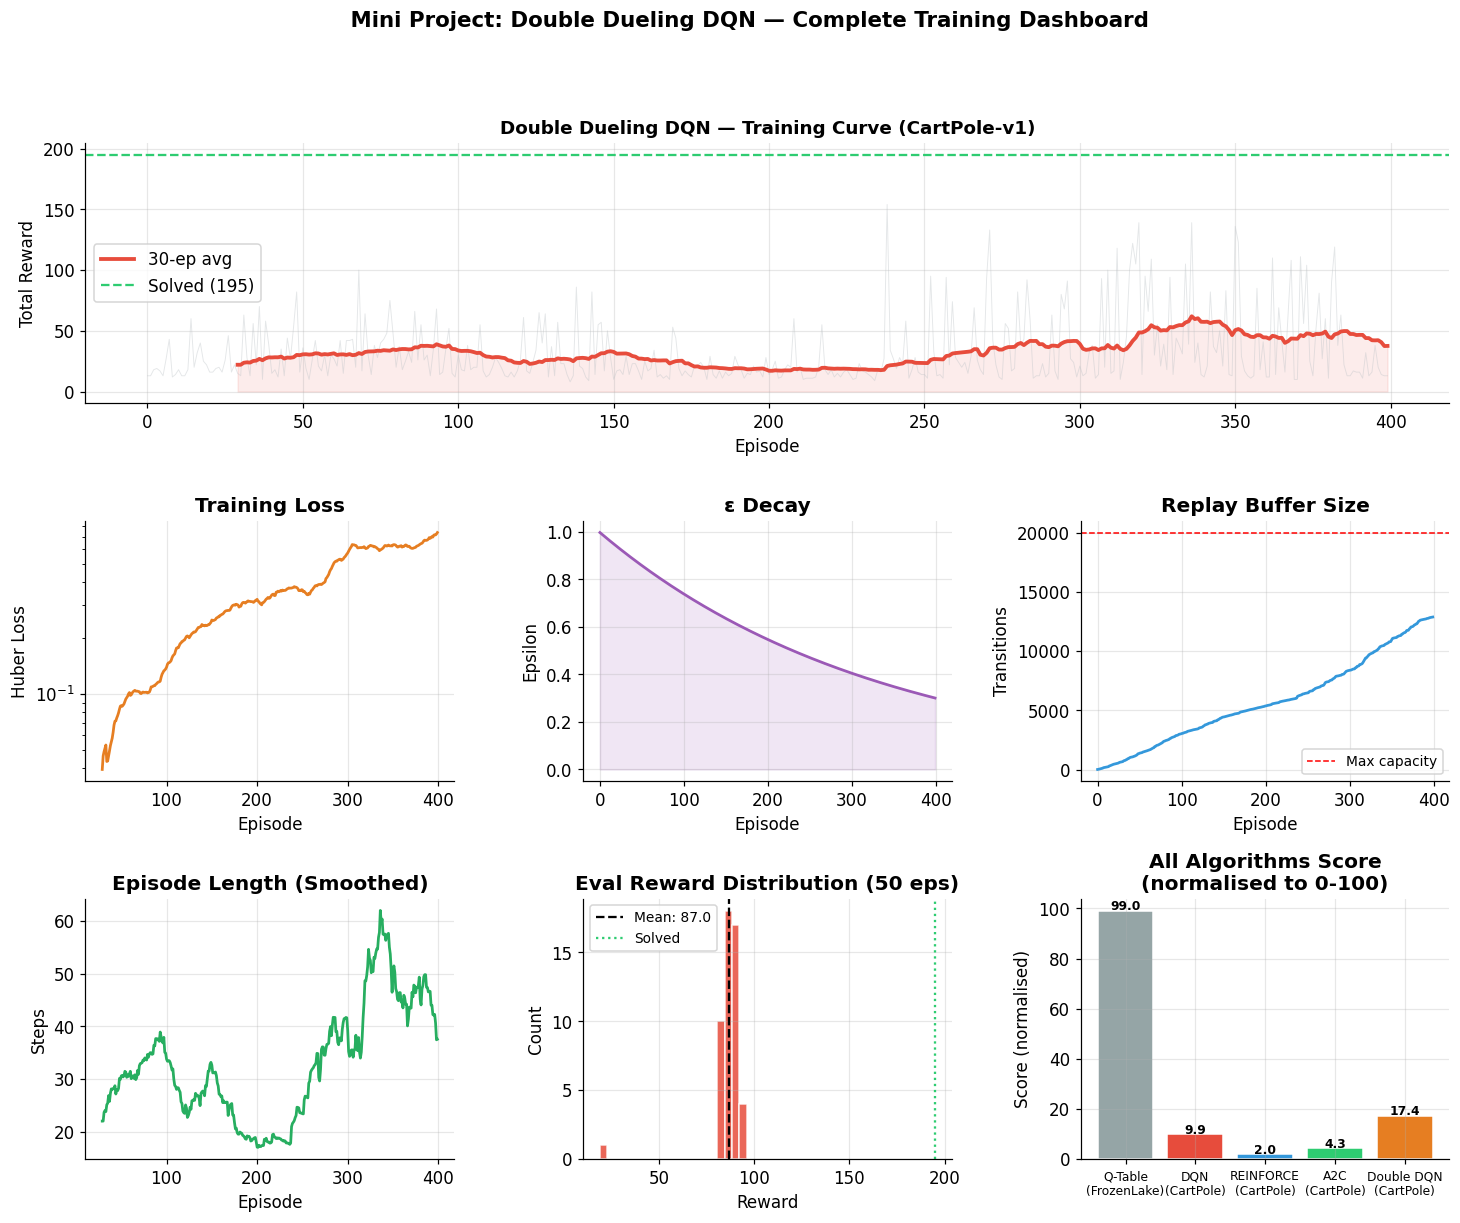

In [25]:
window = 30

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[2, 2])


sm = pd.Series(logs['rewards']).rolling(window).mean()
ax1.plot(logs['rewards'], color='#bdc3c7', linewidth=0.6, alpha=0.4)
ax1.plot(sm,              color='#e74c3c', linewidth=2.5, label=f'{window}-ep avg')
ax1.axhline(195, color='#2ecc71', linestyle='--', linewidth=1.5, label='Solved (195)')
ax1.fill_between(range(len(sm)), sm, alpha=0.1, color='#e74c3c')
ax1.set_title('Double Dueling DQN — Training Curve (CartPole-v1)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.legend()


loss_sm = pd.Series(logs['losses']).rolling(window).mean()
ax2.plot(loss_sm, color='#e67e22', linewidth=1.8)
ax2.set_title('Training Loss', fontweight='bold')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Huber Loss')
ax2.set_yscale('log')


ax3.plot(logs['epsilons'], color='#9b59b6', linewidth=1.8)
ax3.fill_between(range(len(logs['epsilons'])), logs['epsilons'], alpha=0.15, color='#9b59b6')
ax3.set_title('ε Decay', fontweight='bold')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Epsilon')


ax4.plot(logs['buffer_sizes'], color='#3498db', linewidth=1.8)
ax4.axhline(20_000, color='red', linestyle='--', linewidth=1, label='Max capacity')
ax4.set_title('Replay Buffer Size', fontweight='bold')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Transitions')
ax4.legend(fontsize=9)


ep_len_sm = pd.Series(logs['episode_lengths']).rolling(window).mean()
ax5.plot(ep_len_sm, color='#27ae60', linewidth=1.8)
ax5.set_title('Episode Length (Smoothed)', fontweight='bold')
ax5.set_xlabel('Episode')
ax5.set_ylabel('Steps')


ax6.hist(eval_rewards, bins=20, color='#e74c3c', edgecolor='white', alpha=0.85)
ax6.axvline(np.mean(eval_rewards), color='black', linestyle='--',
             linewidth=1.5, label=f'Mean: {np.mean(eval_rewards):.1f}')
ax6.axvline(195, color='#2ecc71', linestyle=':', linewidth=1.5, label='Solved')
ax6.set_title('Eval Reward Distribution (50 eps)', fontweight='bold')
ax6.set_xlabel('Reward')
ax6.set_ylabel('Count')
ax6.legend(fontsize=9)


algo_names  = ['Q-Table\n(FrozenLake)', 'DQN\n(CartPole)', 'REINFORCE\n(CartPole)', 'A2C\n(CartPole)', 'Double DQN\n(CartPole)']
algo_scores = [
    win_rate,
    np.mean(dqn_rewards[-100:]),
    np.mean(pg_rewards[-100:]),
    np.mean(a2c_rewards[-100:]),
    np.mean(eval_rewards)
]

scores_norm = [win_rate, 
               np.mean(dqn_rewards[-100:])/5,
               np.mean(pg_rewards[-100:])/5,
               np.mean(a2c_rewards[-100:])/5,
               np.mean(eval_rewards)/5]

bar_colors_final = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#e67e22']
bars = ax7.bar(algo_names, scores_norm, color=bar_colors_final, edgecolor='white')
ax7.set_title('All Algorithms Score\n(normalised to 0-100)', fontweight='bold')
ax7.set_ylabel('Score (normalised)')
ax7.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, scores_norm):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')

fig.suptitle(' Mini Project: Double Dueling DQN — Complete Training Dashboard',
              fontsize=14, fontweight='bold')
plt.show()

---
## 🎉 Congratulations | You have Completed the RL Handbook!

### What You've Mastered

| Section | Concepts & Skills |
|---|---|
| 1. Introduction | RL loop, core concepts, discount factor, algorithm taxonomy |
| 2. MDPs | State/action/reward/transition, Markov property, Bellman equations, Grid World |
| 3. Dynamic Programming | Value iteration, policy iteration, convergence |
| 4. Gym Environments | Gymnasium API, CartPole, FrozenLake, MountainCar, random baseline |
| 5. Q-Learning | TD updates, ε-greedy, Q-table training on FrozenLake |
| 6. DQN | Experience replay, target network, Huber loss, CartPole training |
| 7. Policy Gradients | REINFORCE, stochastic policy, Monte Carlo returns, variance reduction |
| 8. Actor-Critic | A2C, advantage function, entropy bonus, actor & critic losses |
| 9. Exploration | ε-greedy variants, UCB, Boltzmann, decay schedules, multi-armed bandit |
| 10. Mini Project | Double DQN + Dueling networks, full dashboard, performance report |

### 📚 Recommended Next Steps
- **PPO (Proximal Policy Optimization)** — most widely used RL algorithm today
- **SAC (Soft Actor-Critic)** — state-of-the-art for continuous action spaces
- **Multi-Agent RL** — multiple agents learning simultaneously
- **Model-Based RL** — learn environment dynamics (Dreamer, MuZero)
- **Offline RL** — learn from fixed datasets without environment interaction
- **Stable Baselines 3** — production RL library implementing PPO, SAC, TD3, etc.

### 🔗 Useful Resources
- [Spinning Up in Deep RL (OpenAI)](https://spinningup.openai.com/)
- [Stable Baselines 3](https://stable-baselines3.readthedocs.io/)
- [Gymnasium Docs](https://gymnasium.farama.org/)
- [Sutton & Barto — RL: An Introduction (free PDF)](http://incompleteideas.net/book/the-book-2nd.html)
- [David Silver RL Lectures (YouTube)](https://www.youtube.com/playlist?list=PLzuuYNsE1EZAXYR4FJ75jcJseBmo4KQ9-)

---